# Cell typing

In [22]:
import pandas as pd
from anndata import AnnData, read_h5ad
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Make sure you're in the parent directory:

In [1]:
import sys
from pathlib import Path
#TODO try to remove this somehow
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

If you ever want to load an existing H5AD file and skip over the preprocessing:

In [3]:
from anndata import read_h5ad

filename = "../data/processed/anndata/IHOPE14_MedLN_BottomLeft_filtered_arcsinh_cf5_GMM_IHOPE_celltypes.h5ad"
read_h5ad(filename)

AnnData object with n_obs × n_vars = 112174 × 38
    obs: 'Object ID', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Nucleus/Cell area ratio', 'x', 'y', 'CCR6_pos', 'CCR7_pos', 'CD107a_pos', 'CD11c_pos', 'CD14_pos', 'CD141_pos', 'CD163_pos', 'CD1c_pos', 'CD20_pos', 'CD21_pos', 'CD27_pos', 'CD31_pos', 'CD34_pos', 'CD38_pos', 'CD3e_pos', 'CD4_pos', 'CD40_pos', 'CD45_pos', 'CD45RA_pos', 'CD45RO_pos', 'CD57_pos', 'CD68_pos', 'CD69_pos', 'CD79a_pos', 'CD8_pos', 'Collagen IV_pos', 'CXCL13_pos', 'DAPI_pos', 'FOXP3_pos', 'Granzyme B_pos', 'HLA-DR_pos', 'ICOS_pos', 'IFNG_pos', 'Ki67_pos', 'LYVE1_pos', 'PD-1_pos', 'TCF-1_pos', 'Vimentin_pos', 'CD38_low', 'CD38_mid', 'CD38_high', 'CD21_low', 'CD21_mid', 'CD21_high', 'type_B', 'type_T', 'type_unclassified', 'state_B_CD27neg_naive_like', 'state_B_CD27pos_memory_like', 'state_B_resting', 'state_B_GC_like', 'state_B_plasmablast_like', 'subtype_B_naive_like', 'subtype_B_memory_like', 'subtype_B_GC_like', 'subtype_B_plasmablast', 'type_CD4_T', 'type_

Load, filter and normalize your raw data in csv format. Also, make sure to specify which file you're working with to facilitate later analysis.

In [27]:
from scripts import preprocessing
import importlib

# Reload to ensure notebook uses the latest version of the script
importlib.reload(preprocessing)

# Input path, here you need to write the entire raw data file name
csv_in = "../data/raw/IHOPE26_LN_InstanSeq_RAW_RESULTS.csv"

# Keep track of which sample you're working on:
basename = "IHOPE26_LN"

# Output path, you can use this default format based on your basename:
csv_out = f"../data/processed/{basename}_cleaned_raw.csv"

# Clean raw CSV
preprocessing.clean_cell_columns(csv_in, csv_out)

Failed to read ../data/raw/IHOPE26_LN_InstanSeq_RAW_RESULTS.csv as utf-8, trying cp1252...
Created directory: ../data/processed
Cleaned CSV saved to: ../data/processed/IHOPE26_LN_cleaned_raw.csv


In [87]:
# TODO keeping this for now, but may remove
from scripts.preprocessing import clean_cell_columns

csv_in = "../data/raw/IHOPE26_Spleen_InstanSeq_RAW_RESULTS.csv"
csv_out = "../data/processed/IHOPE26_Spleen_2_cleaned_raw.csv"

# Specify this so that you can easily keep track of which sample you're working on
basename = "IHOPE26_Spleen_2"

# Cleaning the data and saving cleaned as a new csv
clean_cell_columns(csv_in, csv_out)

                              Object ID Object type      Parent      ROI  \
0  8e4696c9-7e1e-4bd5-bb7b-952adcf1a14b        Cell  Annotation  Polygon   
1  b50a20da-8487-47e7-9f0a-4673f721f0ec        Cell  Annotation  Polygon   
2  0512f1df-77f4-48de-82b2-0609b67f0a7d        Cell  Annotation  Polygon   
3  f1faa146-0dc6-40b3-9d0b-4af8d440ccf3        Cell  Annotation  Polygon   
4  0b96a3fd-6869-43a0-bbf7-65e35d89fac8        Cell  Annotation  Polygon   

   Centroid X µm  Centroid Y µm  Area µm^2  Length µm  Circularity  Solidity  \
0         507.33         2195.3    11.0104    15.0112       0.6140    0.9163   
1         611.12         2393.0    72.3929    46.7145       0.4169    0.8987   
2         596.71         2397.0    60.9254    45.2867       0.3733    0.8847   
3         601.71         2398.6    30.7358    27.9968       0.4928    0.8914   
4         599.36         2407.5    49.6685    34.2869       0.5309    0.9226   

   ...  CD68: Min  CD68: Max  CD68: Std.Dev.  Nucleus: Area µm

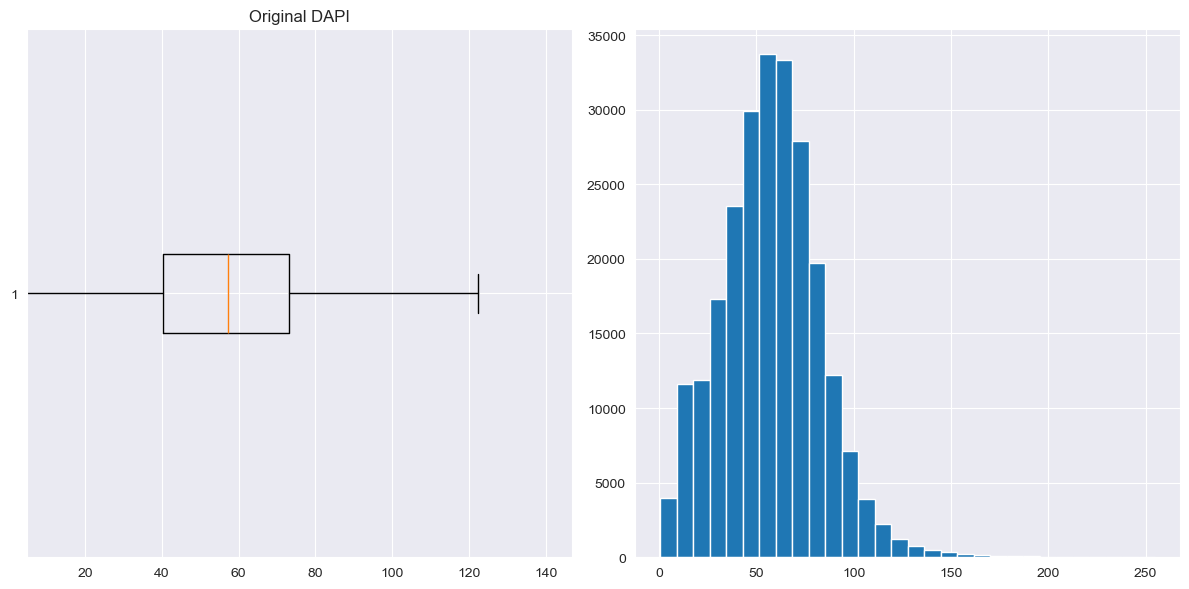

Filtered data saved to: ../data/processed/IHOPE26_LN_cleaned_filtered.csv


In [28]:
from scripts import preprocessing
import importlib

# Reload to ensure the latest version of the script is used
importlib.reload(preprocessing)

# Run preprocessing (specify input file and output name)
input_file = f"../data/processed/{basename}_cleaned_raw.csv"
output_file = f"../data/processed/{basename}_cleaned_filtered.csv"

preprocessing.preprocess(input_file, output_file, plot=True)


**Normalize**

Choose between: "arcsinh", "z-score" and "none".

For arcsinh, you can specify a cofactor

Saved CSV to: ../data/processed/IHOPE26_LN_cleaned_filtered_arcsinh_cf5.0.csv
Plot saved to: ../results/figures/IHOPE26_LN_cleaned_filtered_arcsinh_cf5.0_distributions.png


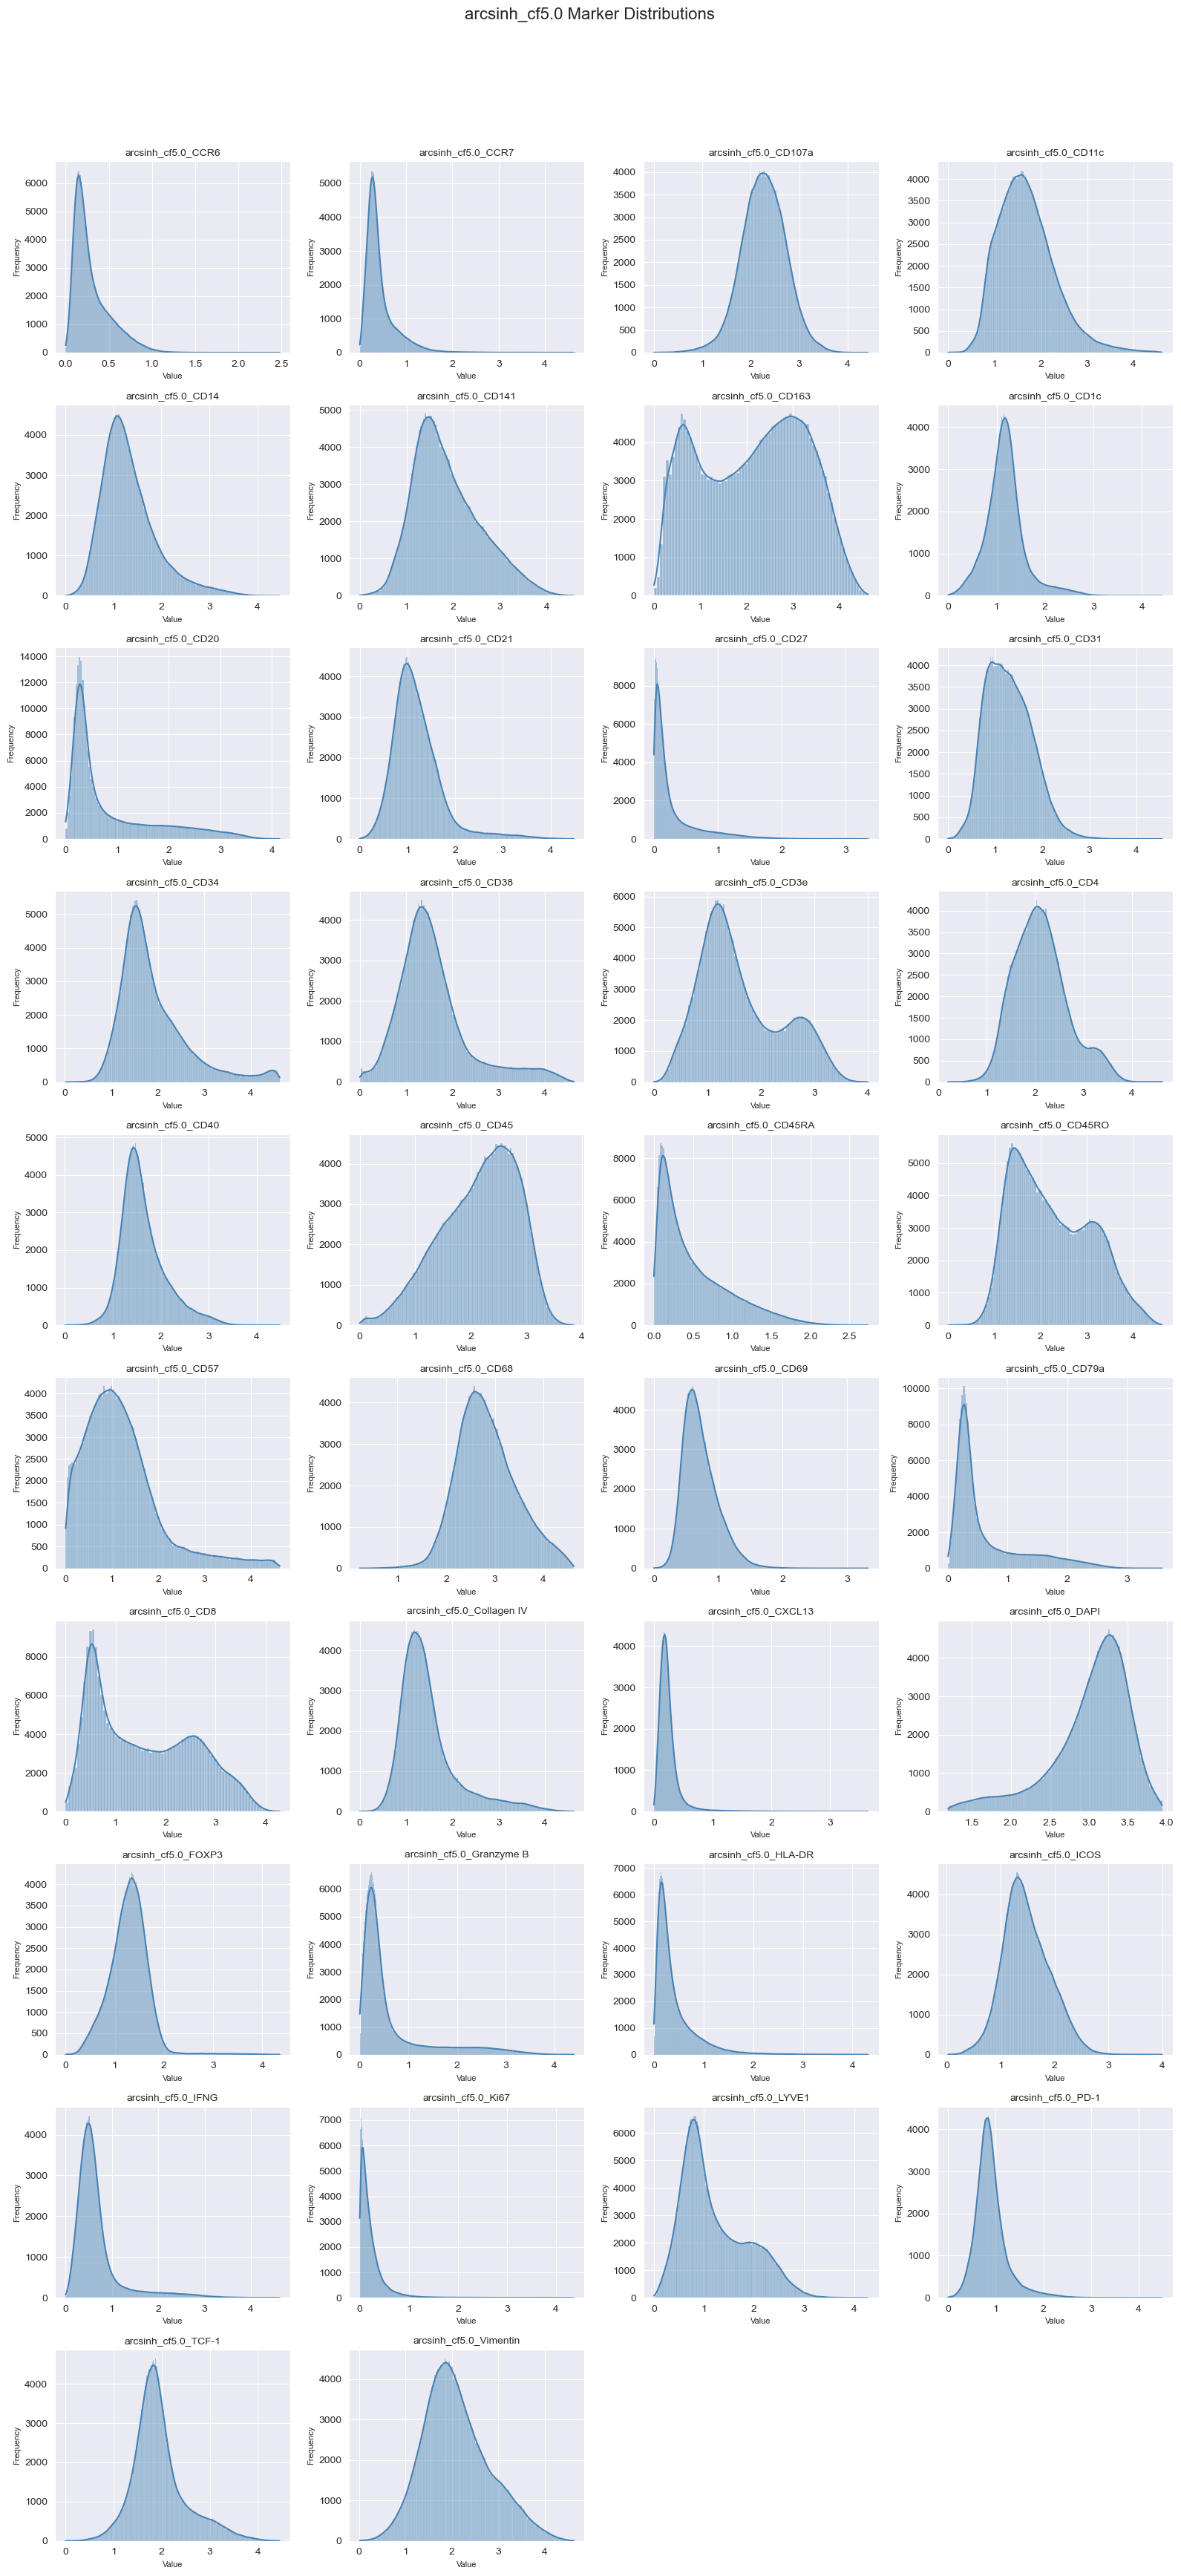

In [29]:
from scripts.transforms import apply_transform

method = "arcsinh"
cofactor = 5.0    # Comment out if not applying arcsinh
input_file = f"../data/processed/{basename}_cleaned_filtered.csv"
output_file = f"../data/processed/{basename}_cleaned_filtered_arcsinh_cf5.0.csv"

df_out, markers, metadata, fig = apply_transform(
    input_file=input_file,
    method=method,
    cofactor=cofactor, # Comment out if not applying arcsinh
    output_file=output_file,
    save_plot=True
)

# Rule-based cell typing
Each cell type will correspond to a column in the AnnData object, with a boolean True/False for every cell type in every cell.

In [67]:
import importlib
import scripts.anndata_helpers

# Reload the module after editing
importlib.reload(scripts.anndata_helpers)

<module 'scripts.anndata_helpers' from '/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/anndata_helpers.py'>

In [24]:
from scripts.anndata_helpers import load_and_build_anndata, save_h5ad

# Read file and create AnnData object
filename = f"../data/processed/{basename}_cleaned_filtered_arcsinh_cf5.0.csv"
adata = load_and_build_anndata(filename)

Dropping 20287 rows with NaN in 'Nucleus/Cell area ratio'


In [13]:
print("adata summary: ")
print(adata)
print("adata X shape: ")
print(adata.X.shape)
print("adata spatial data dimensions: ")
print(adata.obsm['spatial'].shape)
print("adata var: ")
print(adata.var)
print("adata var names: ")
print(adata.var_names)

adata summary: 
AnnData object with n_obs × n_vars = 67032 × 38
    obs: 'Object ID', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Nucleus/Cell area ratio', 'x', 'y'
    obsm: 'spatial'
adata X shape: 
(67032, 38)
adata spatial data dimensions: 
(67032, 2)
adata var: 
Empty DataFrame
Columns: []
Index: [arcsinh_cf5.0_CCR6, arcsinh_cf5.0_CCR7, arcsinh_cf5.0_CD107a, arcsinh_cf5.0_CD11c, arcsinh_cf5.0_CD14, arcsinh_cf5.0_CD141, arcsinh_cf5.0_CD163, arcsinh_cf5.0_CD1c, arcsinh_cf5.0_CD20, arcsinh_cf5.0_CD21, arcsinh_cf5.0_CD27, arcsinh_cf5.0_CD31, arcsinh_cf5.0_CD34, arcsinh_cf5.0_CD38, arcsinh_cf5.0_CD3e, arcsinh_cf5.0_CD4, arcsinh_cf5.0_CD40, arcsinh_cf5.0_CD45, arcsinh_cf5.0_CD45RA, arcsinh_cf5.0_CD45RO, arcsinh_cf5.0_CD57, arcsinh_cf5.0_CD68, arcsinh_cf5.0_CD69, arcsinh_cf5.0_CD79a, arcsinh_cf5.0_CD8, arcsinh_cf5.0_Collagen IV, arcsinh_cf5.0_CXCL13, arcsinh_cf5.0_DAPI, arcsinh_cf5.0_FOXP3, arcsinh_cf5.0_Granzyme B, arcsinh_cf5.0_HLA-DR, arcsinh_cf5.0_ICOS, arcsinh_cf5.0_IFNG, arcsin

Apply marker positivity thresholds (GMM intersections):

In [25]:
from scripts.annotation import compute_positivity_matrix

# Annotate all cells with GMM-based positivity for canonical markers, fallback to percentile if unimodal #TODO add multimodal
adata, thresholds, best_gmms = compute_positivity_matrix(
    adata,
    quantile=0.8,
    random_state=0
)

Added 38 _pos columns to adata.obs
Unimodal markers: []
Bimodal markers: ['CCR6', 'CCR7', 'CD107a', 'CD11c', 'CD14', 'CD141', 'CD163', 'CD1c', 'CD20', 'CD21', 'CD27', 'CD31', 'CD34', 'CD38', 'CD3e', 'CD4', 'CD40', 'CD45', 'CD45RA', 'CD45RO', 'CD57', 'CD68', 'CD69', 'CD79a', 'CD8', 'Collagen IV', 'CXCL13', 'DAPI', 'FOXP3', 'Granzyme B', 'HLA-DR', 'ICOS', 'IFNG', 'Ki67', 'LYVE1', 'PD-1', 'TCF-1', 'Vimentin']


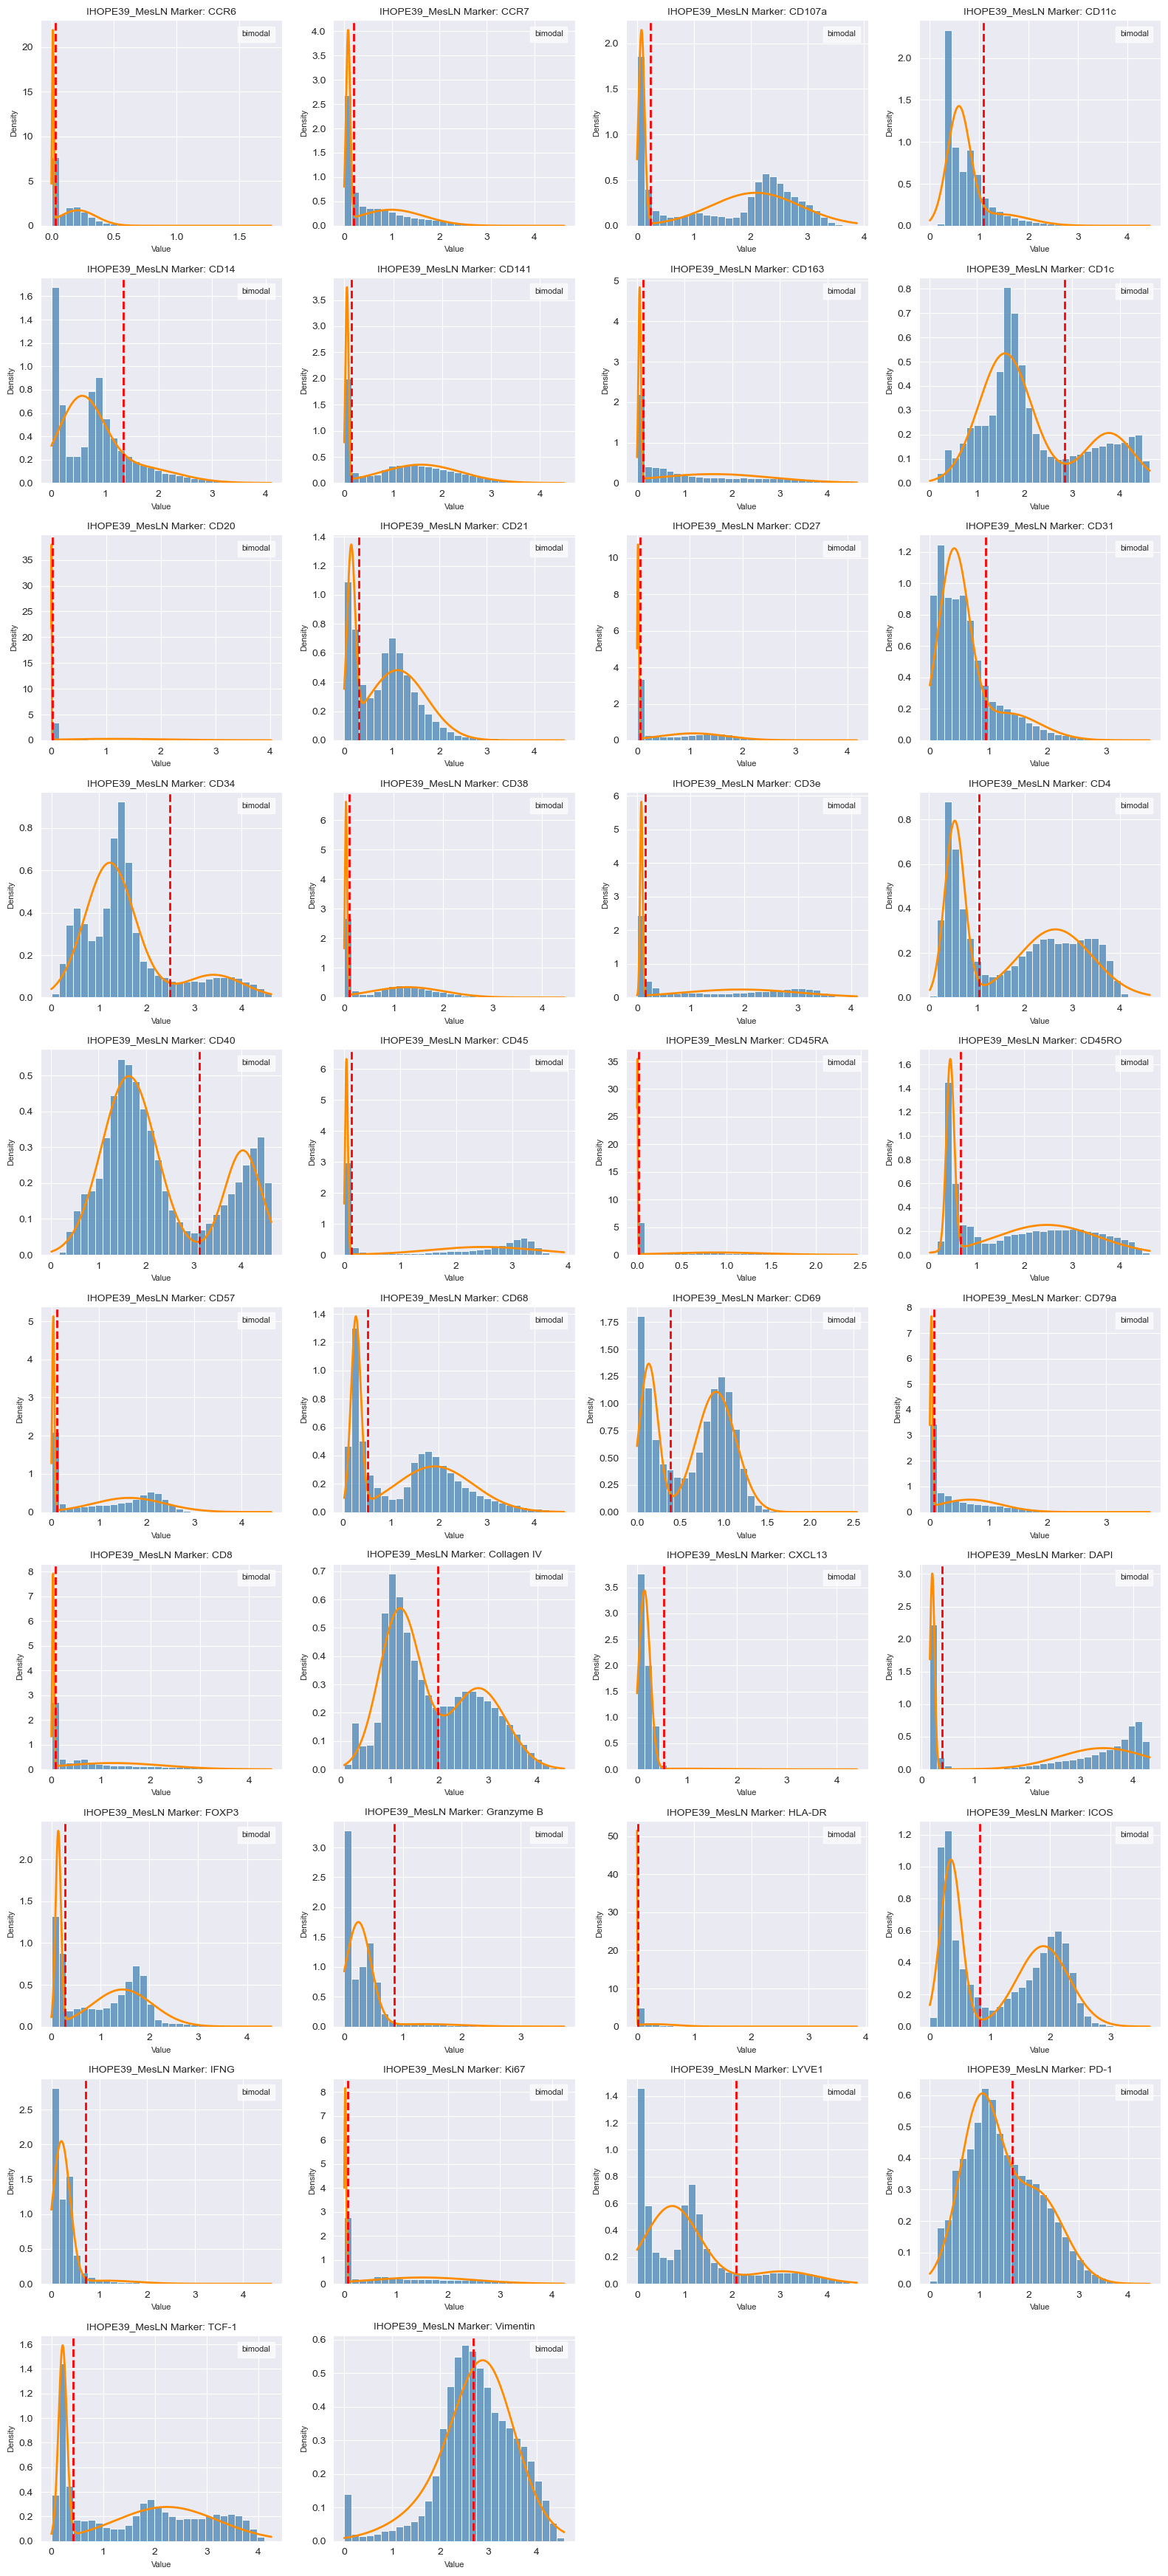

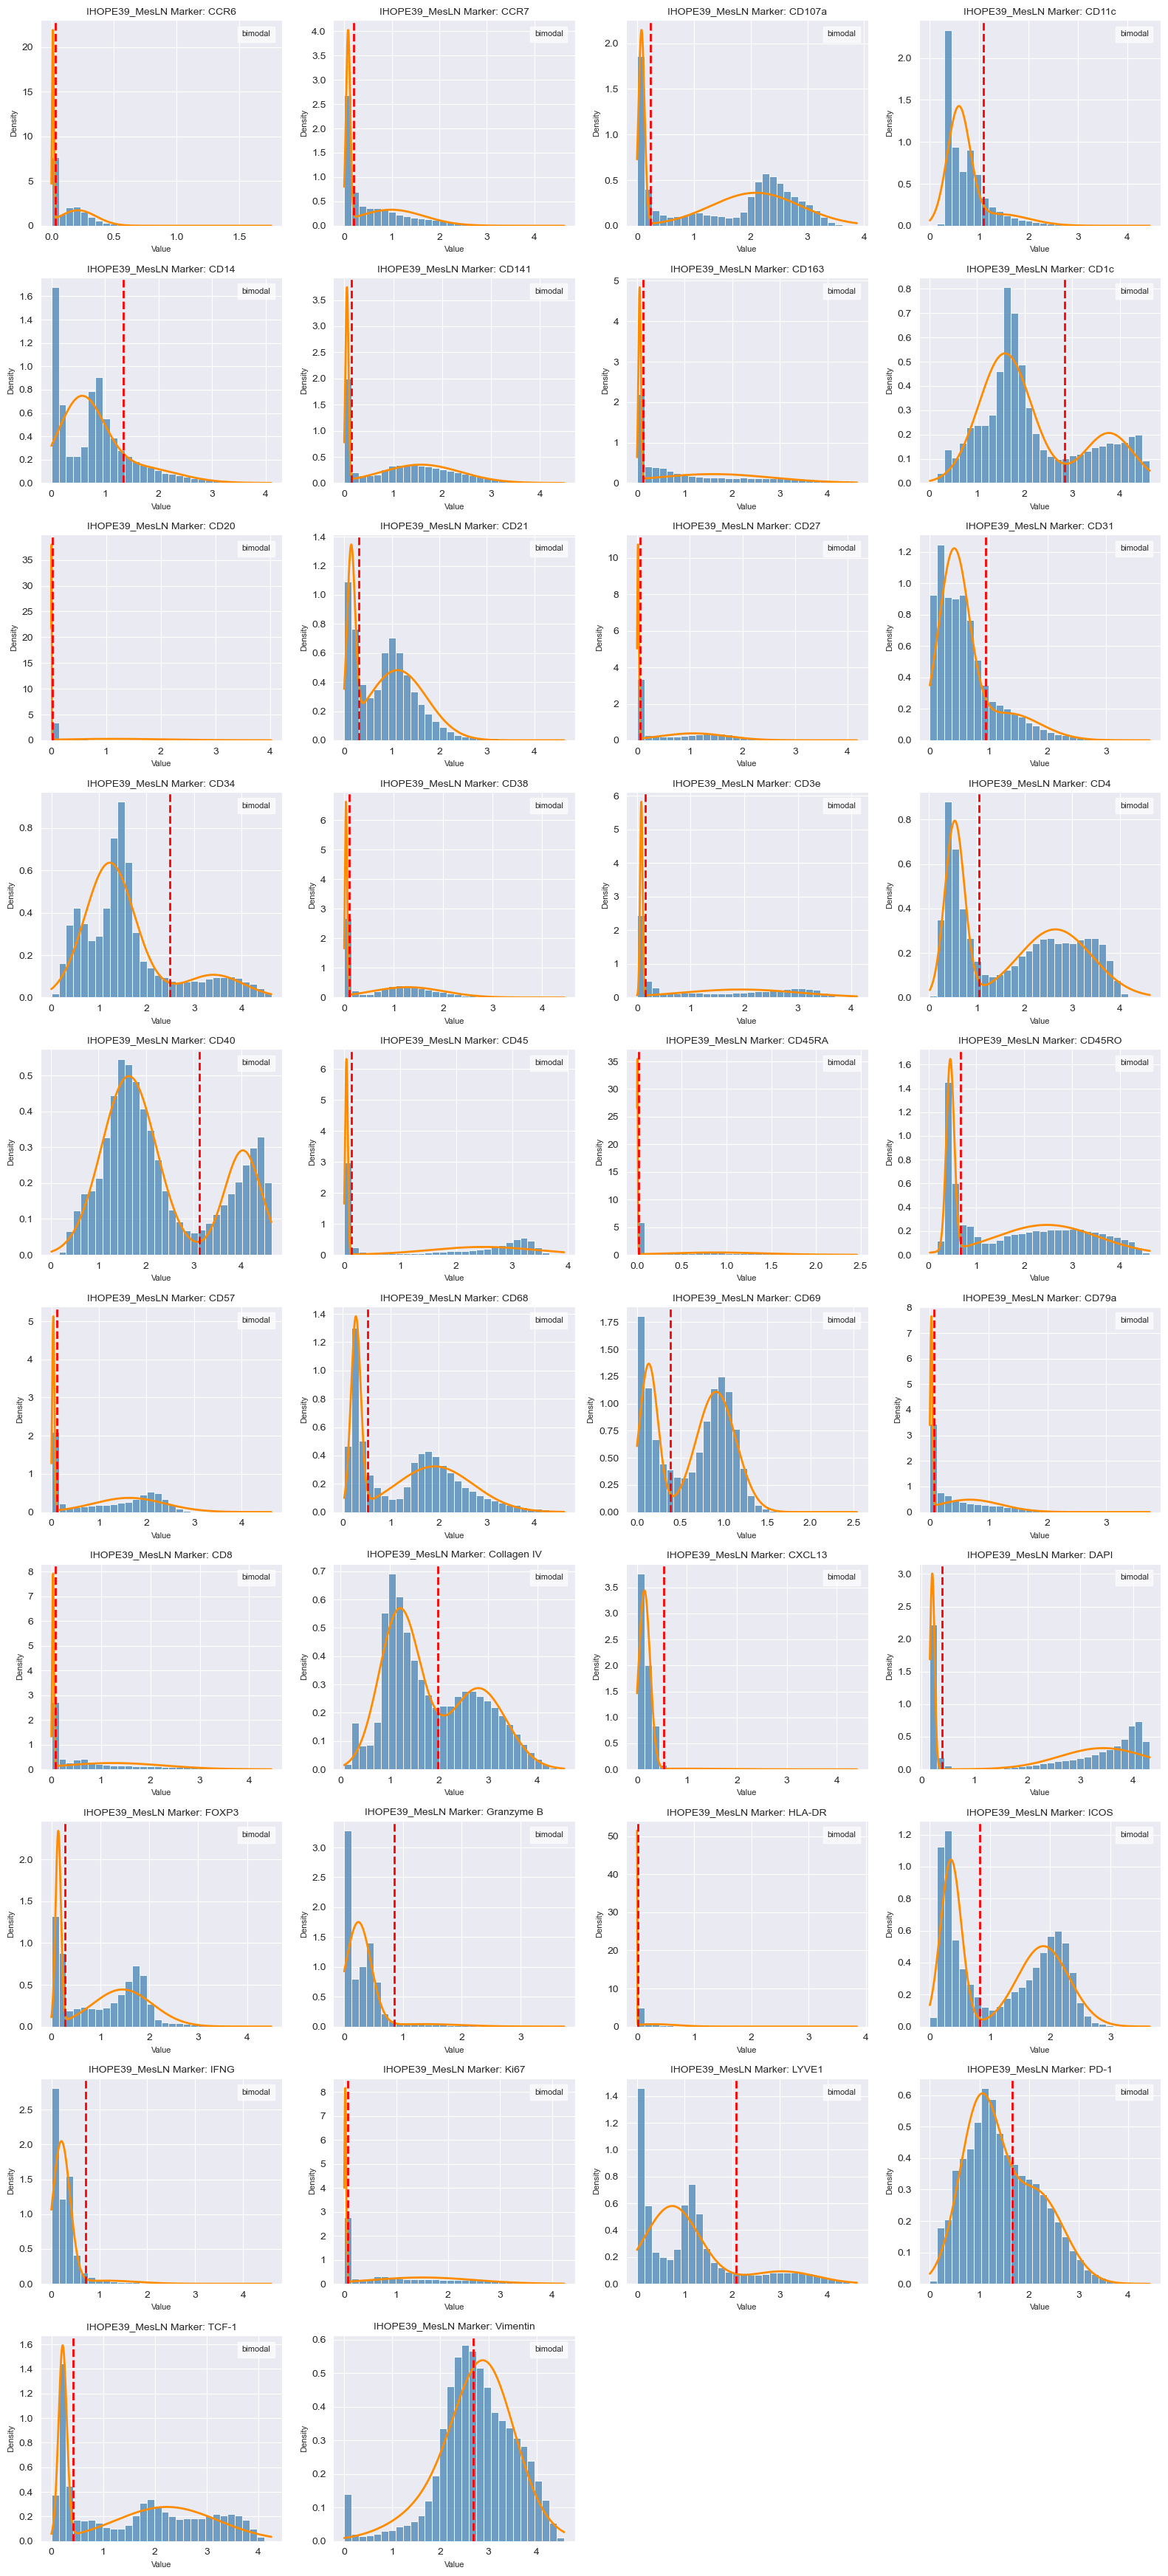

In [26]:
# Visualize the distributions and thresholds:
from scripts.annotation import plot_marker_gmm_adata
plot_marker_gmm_adata(adata,
                      thresholds,
                      best_gmms,
                      title_prefix=f"{basename} Marker: ",
                      save=False,
                      filename="GMM_histograms")

Optional: add high/low levels to marker of interest.

Specify marker name, quantiles to label as low and high, and a recommended plot for visualization.

In [34]:
import importlib
import scripts.annotation

# Reload the module after editing
importlib.reload(scripts.annotation)

<module 'scripts.annotation' from '/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/annotation.py'>


CD38 intensity tiers (restricted to CD38_pos cells)
  low_q  = 0.33  -> threshold = 0.9607
  high_q = 0.90 -> threshold = 2.2116
Counts:
  total cells:   67032
  CD38_pos:  42360
  CD38_low:  13979  (33.0%)
  CD38_mid:  24145  (57.0%)
  CD38_high: 4236  (10.0%)


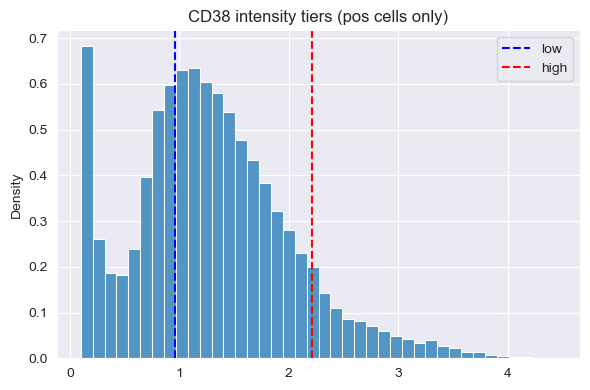

AnnData object with n_obs × n_vars = 67032 × 38
    obs: 'Object ID', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Nucleus/Cell area ratio', 'x', 'y', 'CCR6_pos', 'CCR7_pos', 'CD107a_pos', 'CD11c_pos', 'CD14_pos', 'CD141_pos', 'CD163_pos', 'CD1c_pos', 'CD20_pos', 'CD21_pos', 'CD27_pos', 'CD31_pos', 'CD34_pos', 'CD38_pos', 'CD3e_pos', 'CD4_pos', 'CD40_pos', 'CD45_pos', 'CD45RA_pos', 'CD45RO_pos', 'CD57_pos', 'CD68_pos', 'CD69_pos', 'CD79a_pos', 'CD8_pos', 'Collagen IV_pos', 'CXCL13_pos', 'DAPI_pos', 'FOXP3_pos', 'Granzyme B_pos', 'HLA-DR_pos', 'ICOS_pos', 'IFNG_pos', 'Ki67_pos', 'LYVE1_pos', 'PD-1_pos', 'TCF-1_pos', 'Vimentin_pos', 'CD38_low', 'CD38_mid', 'CD38_high'
    uns: 'thresholds', 'intensity_thresholds'
    obsm: 'spatial'

In [35]:
from scripts import annotation

annotation.add_intensity_tiers(
    adata,
    marker="CD38",
    low_q=0.33,
    high_q=0.9,
    plot=True
)

In [30]:
import scripts
import scripts.celltype_rules
import importlib

importlib.reload(scripts.celltype_rules)

<module 'scripts.celltype_rules' from '/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/celltype_rules.py'>

In [16]:
from scripts.celltype_rules import assign_cell_types_bool

adata = assign_cell_types_bool(adata)


Branch summary:
  Immune: 40959
  Non_Immune: 26073
  Cells with ≥2 branches: 0
  Cells with no branch: 0
  Total cells: 67032

Type summary:
  Bcell: 232
  Endothelial: 5063
  Immune_Unclassified: 40539
  Myeloid: 2
  Non_Immune_Unclassified: 2553
  Stromal: 20734
  Tcell: 186
  Cells with ≥2 types: 2277
  Cells with no type: 0
  Total cells: 67032

Subtype summary:
  Activated_B: 171
  B_Unclassified: 6
  Basement_Membrane: 19947
  CD4_T: 12
  CD8_T: 52
  Endothelial: 1324
  FDC: 7
  Fibroblast: 20054
  Follicular_like_B: 173
  GC_like_B: 153
  Lymphatic_Endothelial: 278
  Memory_B: 29
  Monocyte_Macrophage: 2
  Myeloid_Unclassified: 0
  Naive_CD4_T: 34231
  Naive_T: 27
  Plasma_like: 22
  Stem_like_memory_T: 2
  Stromal_Unclassified: 3535
  TEMRA_CD8_T: 2860
  T_Unclassified: 15
  TfH_like: 1
  Th17_like: 29
  Tissue_Resident_T: 157
  Treg: 86
  cDC1: 0
  cDC2: 0
  Cells with ≥2 subtypes: 18307
  Cells with no subtype: 3650
  Total cells: 67032



**Check overlap between cell types of interest:**

Nothing will be reported for cell types that have zero overlap.


Overlaps for subtype_TEMRA_CD8_T (2860 cells total):
                       overlap_count  pct_of_target
Basement_Membrane                114       3.986014
Fibroblast                        63       2.202797
Endothelial                       25       0.874126
Naive_T                           21       0.734266
Tissue_Resident_T                 20       0.699301
Treg                              18       0.629371
Stromal_Unclassified              12       0.419580
Th17_like                          8       0.279720
CD8_T                              3       0.104895
Lymphatic_Endothelial              2       0.069930


/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/celltype_rules_updated.py:231: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='overlap_count', y=overlap_df.index, data=overlap_df, palette="viridis")


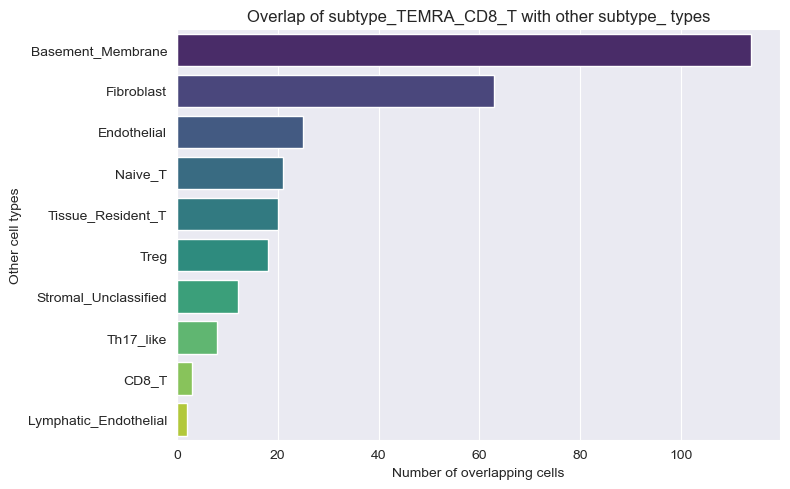

In [17]:
from scripts.celltype_rules import check_celltype_overlap

# TEMRA CD8 T
overlaps = check_celltype_overlap(adata, "TEMRA_CD8_T")

Optional: save anndata object with progress so far

In [18]:
# Save AnnData as h5ad
h5adpath = f"../data/processed/anndata/{basename}_filtered_arcsinh_cf5_GMM.h5ad"
save_h5ad(adata, h5adpath)

# Spatial visualization

In [ ]:
import scripts
import scripts.spatial_plot
import importlib

importlib.reload(scripts.spatial_plot)

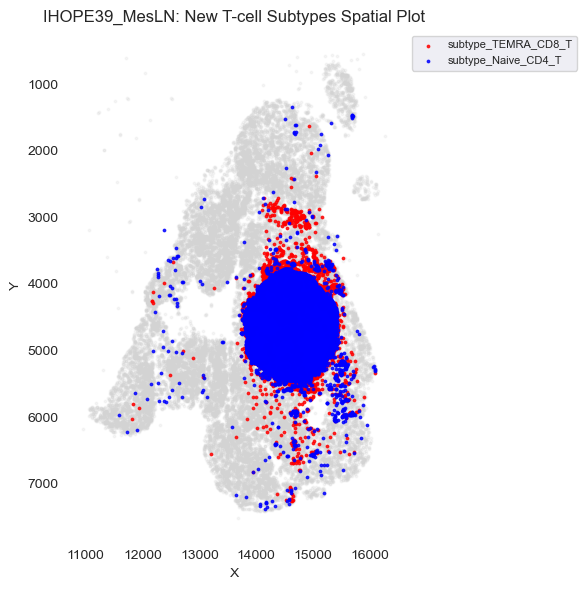

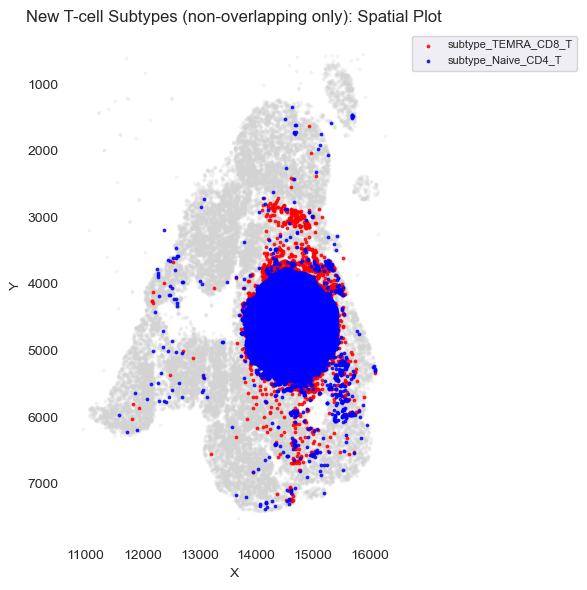

In [19]:
from scripts.spatial_plot import plot_spatial

# List cell types of interest
new_t_cells = ["subtype_TEMRA_CD8_T", "subtype_Naive_CD4_T"]
caption = "New T-cell Subtypes"

# Optional colors
colors = {"subtype_TEMRA_CD8_T": "red", "subtype_Naive_CD4_T": "blue"}

# Plot all cells, allowing overlaps
plot_spatial(
    adata,
    celltypes=new_t_cells,
    colors=colors,
    size=3,
    alpha=0.8,
    title_prefix=f"{basename}: {caption} "
)

# Plot excluding overlapping cells
plot_spatial(
    adata,
    celltypes=new_t_cells,
    colors=colors,
    size=3,
    alpha=0.8,
    exclude_overlaps=True,
    title_prefix=f"{caption} (non-overlapping only): "
)


**Cell type summary in sample**

Use after loading data and running annotation!

This will be used later for statistical comparison between tissues.

In [ ]:
import scripts
import scripts.summary_celltypes
import importlib

importlib.reload(scripts.summary_celltypes)

In [20]:
from scripts.summary_celltypes import summarize_celltypes

df_summary = summarize_celltypes(
    adata,
    filename=f"{basename}_filtered_arcsinh.csv"
)


Cell type summary written to:
  /Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/results/reports/celltype_summary_IHOPE39_MesLN_filtered_arcsinh.csv

Cell type summary:
  level               cell_type                        column  n_cells  pct_cells  total_cells
 branch                  Immune                 branch_Immune    40959       61.1        67032
   type     Immune_Unclassified      type_Immune_Unclassified    40539       60.5        67032
subtype             Naive_CD4_T           subtype_Naive_CD4_T    34231       51.1        67032
 branch              Non_Immune             branch_Non_Immune    26073       38.9        67032
   type                 Stromal                  type_Stromal    20734       30.9        67032
subtype              Fibroblast            subtype_Fibroblast    20054       29.9        67032
subtype       Basement_Membrane     subtype_Basement_Membrane    19947       29.8        67032
   type             Endothelial              type_Endoth